# Loan Dataset Exploration with PySpark

This notebook is set up for the large `data/loan.csv` file using a local Spark session.

Prerequisites:
- Activate the virtual environment in the project root.
- Install the packages from `requirements.txt`.
- Install a Java runtime, since PySpark needs Java to start.


In [1]:
import os
from pathlib import Path

import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

JAVA_HOME = Path('/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home')
os.environ.setdefault('JAVA_HOME', str(JAVA_HOME))
os.environ['PATH'] = f"{JAVA_HOME / 'bin'}:{os.environ['PATH']}"
os.environ.setdefault('SPARK_LOCAL_IP', '127.0.0.1')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
CSV_PATH = DATA_DIR / 'loan.csv'
DICT_PATH = DATA_DIR / 'LCDataDictionary.xlsx'

spark = (
    SparkSession.builder
    .appName('loan-exploration')
    .master('local[*]')
    .config('spark.sql.repl.eagerEval.enabled', 'true')
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')
print(f'CSV exists: {CSV_PATH.exists()} | size: {CSV_PATH.stat().st_size / (1024 ** 3):.2f} GB')
print(f'Data dictionary exists: {DICT_PATH.exists()}')


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/06 20:25:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1
CSV exists: True | size: 1.11 GB
Data dictionary exists: True


In [2]:
dictionary_preview = pd.read_excel(DICT_PATH).head(10)
dictionary_preview

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...
5,annual_inc_joint,The combined self-reported annual income provi...
6,application_type,Indicates whether the loan is an individual ap...
7,avg_cur_bal,Average current balance of all accounts
8,bc_open_to_buy,Total open to buy on revolving bankcards.
9,bc_util,Ratio of total current balance to high credit/...


In [3]:
df = (
    spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(str(CSV_PATH))
)

df.cache()
row_count = df.count()
column_count = len(df.columns)
print(f'Rows: {row_count:,}')
print(f'Columns: {column_count}')


26/06/06 20:25:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 2:=============================>                            (5 + 5) / 10]

Rows: 2,260,668
Columns: 145


## Step 1: Initial Standardization

These cells keep `df` as the raw dataset and build `df_step1` as the first cleaned working frame.


In [4]:
string_columns = [name for name, dtype in df.dtypes if dtype == 'string']

df_trimmed = df.select([
    F.trim(F.col(c)).alias(c) if c in string_columns else F.col(c)
    for c in df.columns
])

df.filter(F.col('term') != F.trim(F.col('term'))).select('term').distinct().show(truncate=False)

+----------+
|term      |
+----------+
| 36 months|
| 60 months|
+----------+



In [5]:
placeholder_strings = ['', 'NULL', 'null', 'N/A', 'n/a']

df_nulls = df_trimmed.select([
    F.when(F.col(c).isin(placeholder_strings), None).otherwise(F.col(c)).alias(c)
    if c in string_columns else F.col(c)
    for c in df_trimmed.columns
])

df_nulls.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c)
    for c in ['id', 'member_id', 'url', 'desc']
]).show()

+-------+---------+-------+-------+
|     id|member_id|    url|   desc|
+-------+---------+-------+-------+
|2260668|  2260668|2260667|2134855|
+-------+---------+-------+-------+



In [6]:
term_digits = F.regexp_extract(F.col('term'), r'(\d+)', 1)

df_term = df_nulls.withColumn(
    'term',
    F.when(F.col('term').isNull(), None)
    .when(term_digits == '', None)
    .otherwise(term_digits.cast('int'))
)

df_term.groupBy('term').count().orderBy('term').show()

+----+-------+
|term|  count|
+----+-------+
|  36|1609754|
|  60| 650914|
+----+-------+



In [7]:
emp_length_digits = F.regexp_extract(F.col('emp_length'), r'(\d+)', 1)

df_emp_length = df_term.withColumn(
    'emp_length',
    F.when(F.col('emp_length').isNull(), None)
    .when(F.col('emp_length') == '< 1 year', F.lit(0))
    .when(F.col('emp_length') == '10+ years', F.lit(10))
    .when(emp_length_digits == '', None)
    .otherwise(emp_length_digits.cast('int'))
)

df_emp_length.groupBy('emp_length').count().orderBy('emp_length').show(15)

+----------+------+
|emp_length| count|
+----------+------+
|      NULL|146908|
|         0|189988|
|         1|148403|
|         2|203676|
|         3|180753|
|         4|136605|
|         5|139698|
|         6|102628|
|         7| 92695|
|         8| 91914|
|         9| 79395|
|        10|748005|
+----------+------+



In [8]:
zip_prefix = F.regexp_extract(F.col('zip_code'), r'^(\d{3})', 1)

df_step1 = df_emp_length.withColumn(
    'zip_code',
    F.when(F.col('zip_code').isNull(), None)
    .when(zip_prefix == '', None)
    .otherwise(zip_prefix)
)

df_step1.select('zip_code').show(15, truncate=False)

+--------+
|zip_code|
+--------+
|109     |
|713     |
|490     |
|985     |
|212     |
|461     |
|606     |
|460     |
|327     |
|068     |
|711     |
|300     |
|840     |
|278     |
|413     |
+--------+
only showing top 15 rows


## Step 2: Parse Month-Year Fields To Dates

These columns use the `MMM-YYYY` pattern and will be normalized to the first day of the month.


In [9]:
date_columns = [
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',
]

date_pattern = r'^[A-Za-z]{3}-\d{4}$'

df_step2 = df_step1

for c in date_columns:
    df_step2 = (
        df_step2
        .withColumn(f'{c}_invalid_raw', F.col(c).isNotNull() & (~F.col(c).rlike(date_pattern)))
        .withColumn(
            c,
            F.when(F.col(c).rlike(date_pattern), F.to_date(F.col(c), 'MMM-yyyy'))
             .otherwise(None)
        )
    )

In [10]:
df_step2.select(
    'issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d'
).printSchema()

df_step2.select(
    'issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d'
).show(10, truncate=False)

root
 |-- issue_d: date (nullable = true)
 |-- earliest_cr_line: date (nullable = true)
 |-- last_pymnt_d: date (nullable = true)
 |-- next_pymnt_d: date (nullable = true)
 |-- last_credit_pull_d: date (nullable = true)

+----------+----------------+------------+------------+------------------+
|issue_d   |earliest_cr_line|last_pymnt_d|next_pymnt_d|last_credit_pull_d|
+----------+----------------+------------+------------+------------------+
|2018-12-01|2001-04-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|1987-06-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2011-04-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2006-02-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2000-12-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2002-09-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2004-11-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|1997-11-01      |

# Step 3: Remove Unusable Or Low-Value Columns
# Drop id, member_id, and url and then review and drop desc and title.

In [11]:
df_step3 = df_step2.drop('id', 'member_id', 'url')

print('Columns after immediate drop:', len(df_step3.columns))
print('Dropped columns present?', [c for c in ['id', 'member_id', 'url'] if c in df_step3.columns])

Columns after immediate drop: 147
Dropped columns present? []


In [12]:
desc_title_review = df_step3.select(
    F.sum(F.col('desc').isNull().cast('int')).alias('desc_missing_rows'),
    F.sum(F.col('title').isNull().cast('int')).alias('title_missing_rows'),
    F.count('desc').alias('desc_non_null_rows'),
    F.count('title').alias('title_non_null_rows'),
    F.approx_count_distinct('title').alias('title_approx_distinct')
)

# desc_title_review.show(truncate=False)

df_step3.groupBy('title').count().orderBy(F.desc('count')).show(160, truncate=False)

+------------------------------+-------+
|title                         |count  |
+------------------------------+-------+
|Debt consolidation            |1153643|
|Credit card refinancing       |469701 |
|Home improvement              |137495 |
|Other                         |127713 |
|Major purchase                |44840  |
|Medical expenses              |25389  |
|NULL                          |23325  |
|Business                      |20822  |
|Car financing                 |20526  |
|Debt Consolidation            |16414  |
|Vacation                      |14456  |
|Moving and relocation         |13800  |
|Home buying                   |12715  |
|Consolidation                 |5679   |
|debt consolidation            |5085   |
|Debt Consolidation Loan       |3866   |
|Credit Card Consolidation     |2448   |
|consolidation                 |2268   |
|Personal Loan                 |2188   |
|Home Improvement              |1864   |
|Consolidation Loan            |1828   |
|Credit Card Ref

In [13]:
title_normalized = F.lower(
    F.trim(
        F.regexp_replace(
            F.regexp_replace(F.col('title'), '_', ' '),
            r'\\s+',
            ' '
        )
    )
)

title_grouped = (
    F.when(F.col('title_normalized').isNull(), F.lit(None).cast('string'))
    .when(
        F.col('title_normalized').rlike(r'consol|consolidat|consolodat'),
        F.lit('debt_consolidation')
    )
    .when(
        F.col('title_normalized').rlike(r'^debt cons$|^debt con$|^debt cons\.$|^debt con\.$|^debtcon$|^debtcons$|^dc$|^dc loan$|^debt cons loan$|^debt conso$|^conso$|consilidation|debt considation|debt consilidation|debt consildation|debt conslidation|debt consalidation|debt consoildation|debt consoidation|debt concolidation|debt cosolidation|consalidation|cosolidation'),
        F.lit('debt_consolidation')
    )
    .when(
        F.col('title_normalized').rlike(
            r'(credit|card|cards|cc).*(refi|refinanc)|(refi|refinanc).*(credit|card|cards|cc)|^refi$|^refinance$|^credit refinance$|^cc refi$|^cc refinance$'
        ),
        F.lit('credit_card_refinancing')
    )
    .when(
        F.col('title_normalized').rlike(r'^refinancing$|^refinance loan$|^refi loan$|loan refinance|refinancing loan|refinance debt|debt refinance|debt refi|debt refinancing|better rate|lower interest rate|lower interest|lower rate|ccr|credit card re-fi'),
        F.lit('credit_card_refinancing')
    )
    .when(
        F.col('title_normalized').rlike(
            r'(credit|card|cards|cc).*(pay ?off|payoff|pay-off|payment|payments|repayment|reduction|elimination|debt|loan|help|gone|killer|debit)|(pay ?off|payoff|paying off|pay|get rid of).*(credit|card|cards|cc)|^credit$|^credit card$|^credit cards$|^creditcard$|^creditcards$|^cards?$|^cc$|^ccc$|^cc payoff$|^cc loan$|^credit payoff$|no more credit cards|no more cards|bye bye credit cards|goodbye credit cards|get rid of credit cards|credit cards gone|^discover$|^amex$|^american express$|^capital one$|^chase$|amex payoff|discover payoff|chase payoff'
        ),
        F.lit('credit_card_related')
    )
    .when(
        F.col('title_normalized').rlike(r'home improvement|home improvements|homeimprovement|home improvment|home inprovement|home improve|home improv|home project|^improvement$|^improvements$|^improvement loan$|home repair|home repairs|^repairs$|^house$|^roof$|^new roof$|^roof loan$|roof repair|roof replacement|kitchen remodel|^new kitchen$|^kitchen$|^pool$|^pool loan$|pool remodel|swimming pool|hot tub|^remodel$|home remodel|basement remodel|bathroom remodel|^new bathroom$|^bathroom$|^garage$|^basement$|home renovation|^renovation$|home addition|^addition$|^backyard$|^deck$|^windows$|^fence$|landscaping|home sweet home'),
        F.lit('home_improvement')
    )
    .when(F.col('title_normalized').rlike(r'^home$|^home loan$|^homeloan$|^new home$'), F.lit('home_related'))
    .when(F.col('title_normalized').rlike(r'home buying|home down payment|home purchase|house loan|land purchase|investment property'), F.lit('home_buying'))
    .when(F.col('title_normalized').rlike(r'major purchase'), F.lit('major_purchase'))
    .when(F.col('title_normalized').rlike(r'boat|engagement ring|^ring$|^purchase$|christmas'), F.lit('major_purchase'))
    .when(F.col('title_normalized').rlike(r'green loan'), F.lit('green_loan'))
    .when(F.col('title_normalized').rlike(r'personal'), F.lit('personal_loan'))
    .when(F.col('title_normalized').rlike(r'business|working capital'), F.lit('business'))
    .when(F.col('title_normalized').rlike(r'medical|surgery|dental|dental work'), F.lit('medical_expenses'))
    .when(F.col('title_normalized').rlike(r'wedding'), F.lit('wedding'))
    .when(F.col('title_normalized').rlike(r'moving|relocation'), F.lit('moving_and_relocation'))
    .when(F.col('title_normalized').rlike(r'vacation'), F.lit('vacation'))
    .when(F.col('title_normalized').rlike(r'\b(car|auto|vehicle|motorcycle|truck|bike|jeep|harley|camper|atv)\b|bike loan|rv loan'), F.lit('car_financing'))
    .when(F.col('title_normalized').rlike(r'bills?|pay off bills|unexpected expenses|expenses|emergency|emergency loan|legal fees'), F.lit('bill_payoff'))
    .when(
        F.col('title_normalized').rlike(r'debt free|debtfree|get out of debt|get outta debt|getting out of debt|getoutofdebt|out of debt|outofdebt|fresh start|freshstart|new start|newstart|new beginning|new begining|new life|relief|freedom|free at last|free|back on track|starting over|starting fresh|start over|clean slate|clean up|cleanup|breathing room|lifesaver|life saver|debt reduction|reduce debt|debt help|debt buster|debt be gone|debt gone|debt away|debt elimination|debt eliminator|no more debt|piece of mind|peace of mind|light at the end of the tunnel|future|getting ahead|get ahead|get rid of debt|catch up|catching up|helping hand|second chance|2nd chance|hope|blessing|recovery|restart|regroup|getting it together|get it together|save money|saving money|saving|savings|bail out|bailout|need help|help loan|help me|help me out|my help|debt control|debt management|debt restructure|debt restructuring|debt solution|debt fix|debt reducer|better life|happiness|happy days|happiness|salvation|rebuild|progress|success|out from under|money saver|saver|save'),
        F.lit('debt_relief')
    )
    .when(F.col('title_normalized').rlike(r'debt payoff|debt pay off|debt pay|pay off debt|pay off loans|paying off debt|paying it off|paid off|payoff debt|debt repayment|debt payment|repayment|payment|the payoff|payback|repay|pay-off|pay down|paydown|pay debt|paydebt|payoffdebt|debtpayoff|clear debt|debt down|lower debt|my debt|^debit$|^debtloan$|^debt loan$|^debts$|^dept$|^debt1$|^debt$|^payoff$|^pay off$|^pay offs$|^payoffs$|^payoff loan$|^payoffloan$|^pay off loan$|^loan payoff$|pay it off|payitoff|pay it down|one payment|snowball'), F.lit('debt_payoff'))
    .when(F.col('title_normalized').rlike(r'^loan ?[0-9]*$|^[0-9]{4} loan$|^[0-9]{4}$|^loan #[0-9]+$|^loan one$|^2nd loan$|^second loan$|^my first loan$|^my loan$|^myloan$|^other loan$|^small loan$|^quick loan$|^bridge loan$|^loan for me$|^loan request$|^one loan$|^my money$|^my lending club loan$|^lending club loan$|^lendingclub loan$|^club loan$|^lcloan$|^lending club$|^lendingclub$|^lendingclubloan$|^lending$|^lending loan$|^lc loan$|^new loan$|^first loan$|^first$|^second$|^short term loan$|^short loan$|^short term$|^the loan$|^smart loan$|^main$|^one$|^mine$|^me$|^money$|^new$'), F.lit('generic_loan'))
    .when(F.col('title_normalized').rlike(r'^taxes$|^tax loan$|^irs$'), F.lit('taxes'))
    .when(F.col('title_normalized').rlike(r'^student loan$'), F.lit('student_loan'))
    .when(F.col('title_normalized').rlike(r'^school$|^education$'), F.lit('education'))
    .when(F.col('title_normalized').rlike(r'^help$|^investment$|^finance$|^family$|^family loan$|^cash$|^happy$|^thank you$|^thanks$|^life$'), F.lit('other'))
    .otherwise(F.col('title_normalized'))
)

df_step3 = (
    df_step3
    .withColumn('title_normalized', title_normalized)
    .withColumn('title_grouped', title_grouped)
)

df_step3.groupBy('title_grouped').count().orderBy(F.desc('count')).show(200, truncate=False)

df_step3_pruned = df_step3.drop('desc')

print('Columns after candidate drop:', len(df_step3_pruned.columns))
print('Dropped columns present?', [c for c in ['desc'] if c in df_step3_pruned.columns])

+--------------------------+-------+
|title_grouped             |count  |
+--------------------------+-------+
|debt_consolidation        |1218168|
|credit_card_refinancing   |478518 |
|home_improvement          |145176 |
|other                     |128323 |
|major_purchase            |46133  |
|medical_expenses          |27057  |
|car_financing             |24031  |
|NULL                      |23325  |
|business                  |23239  |
|credit_card_related       |19407  |
|vacation                  |15136  |
|moving_and_relocation     |15090  |
|debt_relief               |15053  |
|home_buying               |13085  |
|debt_payoff               |10303  |
|personal_loan             |6684   |
|generic_loan              |6483   |
|bill_payoff               |3067   |
|wedding                   |2397   |
|green_loan                |1254   |
|home_related              |822    |
|taxes                     |188    |
|education                 |69     |
|all in one                |56     |
|

In [14]:
# df.printSchema()

In [15]:
# df.select(df.columns[87:94]).show(15, truncate=False)

In [16]:
missing_summary = (
    df.select([
        F.sum(F.col(c).isNull().cast('int')).alias(c)
        for c in df.columns
    ])
    .toPandas()
    .T
    .reset_index()
)

missing_summary.columns = ['column', 'missing_rows']
missing_summary['missing_pct'] = missing_summary['missing_rows'] / row_count
missing_summary.sort_values('missing_pct', ascending=False).head(20)

,column,missing_rows,missing_pct
0,id,2260668,1.000000
1,member_id,2260668,1.000000
18,url,2260667,1.000000
134,orig_projected_additional_accrued_interest,2252240,0.996272
136,hardship_last_payment_amount,2250054,0.995305
135,hardship_payoff_balance_amount,2250054,0.995305
133,hardship_loan_status,2250048,0.995302
132,hardship_dpd,2250048,0.995302
131,hardship_length,2250044,0.995301
128,hardship_start_date,2250044,0.995301


In [17]:
candidate_targets = [c for c in ['loan_status', 'grade', 'sub_grade', 'purpose', 'home_ownership'] if c in df.columns]
candidate_targets

['loan_status', 'grade', 'sub_grade', 'purpose', 'home_ownership']

In [18]:
if 'loan_status' in df.columns:
    (
        df.groupBy('loan_status')
        .count()
        .orderBy(F.desc('count'))
        .show(20, truncate=False)
    )
else:
    print('`loan_status` is not present in the dataset.')


+---------------------------------------------------+-------+
|loan_status                                        |count  |
+---------------------------------------------------+-------+
|Fully Paid                                         |1041952|
|Current                                            |919695 |
|Charged Off                                        |261654 |
|Late (31-120 days)                                 |21897  |
|In Grace Period                                    |8952   |
|Late (16-30 days)                                  |3737   |
|Does not meet the credit policy. Status:Fully Paid |1988   |
|Does not meet the credit policy. Status:Charged Off|761    |
|Default                                            |31     |
|Oct-2015                                           |1      |
+---------------------------------------------------+-------+



In [19]:
numeric_candidates = [
    c for c, t in df.dtypes
    if t in {'int', 'bigint', 'float', 'double', 'decimal'}
]

df.select(numeric_candidates[:15]).summary().show(truncate=False)

[Stage 34:>                                                         (0 + 1) / 1]

+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------------------+------------------------+------------------+------------------+--------------------+---------------------+-----------------+------------------+--------------------+
|summary|loan_amnt         |funded_amnt       |funded_amnt_inv   |int_rate          |installment       |acc_open_past_24mths|bc_open_to_buy    |chargeoff_within_12_mths|delinq_amnt       |mo_sin_old_il_acct|mo_sin_old_rev_tl_op|mo_sin_rcnt_rev_tl_op|mo_sin_rcnt_tl   |mort_acc          |mths_since_recent_bc|
+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------------------+------------------------+------------------+------------------+--------------------+---------------------+-----------------+------------------+--------------------+
|count  |2260668           |2260668           |2260668           |2260668

## Step 4: Persist A Faster Working Snapshot

If the schema looks reasonable, persist the cleaned working frame to Parquet so future analysis does not need to re-read the raw CSV each time.


In [20]:
parquet_path = DATA_DIR / 'loan.parquet'
clean_snapshot = df_step3_pruned if 'df_step3_pruned' in globals() else df

(
    clean_snapshot.write
    .mode('overwrite')
    .parquet(str(parquet_path))
)

print(f'Wrote cleaned Parquet dataset to {parquet_path}')


[Stage 35:===================================================>     (9 + 1) / 10]

Wrote cleaned Parquet dataset to /Users/tendani/Desktop/Loaning/data/loan.parquet


In [21]:
parquet_path = '/Users/tendani/Desktop/Loaning/data/loan.parquet'

In [22]:
df_parquet = spark.read.parquet(str(parquet_path))
parquet_row_count = df_parquet.count()

print(f'Parquet row count: {parquet_row_count:,}')
print(f'Parquet column count: {len(df_parquet.columns):,}')
print(f'Row count matches source: {parquet_row_count == row_count}')

df_parquet.select('loan_status', 'grade', 'purpose').show(5, truncate=False)

Parquet row count: 2,260,668
Parquet column count: 148
Row count matches source: True
+-----------+-----+------------------+
|loan_status|grade|purpose           |
+-----------+-----+------------------+
|Charged Off|D    |debt_consolidation|
|Current    |D    |debt_consolidation|
|Charged Off|C    |debt_consolidation|
|Fully Paid |D    |credit_card       |
|Fully Paid |C    |other             |
+-----------+-----+------------------+
only showing top 5 rows


## Step 5: Numeric Correlations And Distributions

This section profiles the numeric fields in the Parquet snapshot. To keep the notebook responsive on a 2.26M-row dataset, the visual summaries below use a reproducible sample for plotting while still reading from the Parquet dataset.


## Start by reading in parquet file

In [23]:
parquet_path = '/Users/tendani/Desktop/Loaning/data/loan.parquet'

df_parquet = spark.read.parquet(str(parquet_path))
parquet_row_count = df_parquet.count()

print(f'Parquet row count: {parquet_row_count:,}')
print(f'Parquet column count: {len(df_parquet.columns):,}')
print(f'Row count matches source: {parquet_row_count == row_count}')

df_parquet.select('loan_status', 'grade', 'purpose').show(5, truncate=False)

Parquet row count: 2,260,668
Parquet column count: 148
Row count matches source: True
+-----------+-----+------------------+
|loan_status|grade|purpose           |
+-----------+-----+------------------+
|Charged Off|D    |debt_consolidation|
|Current    |D    |debt_consolidation|
|Charged Off|C    |debt_consolidation|
|Fully Paid |D    |credit_card       |
|Fully Paid |C    |other             |
+-----------+-----+------------------+
only showing top 5 rows


In [24]:
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')

# Keep only Spark columns whose dtype is numeric, because correlations and
# numeric distributions do not make sense for string/categorical fields.
numeric_types = {'int', 'bigint', 'float', 'double', 'decimal'}
numeric_columns = [c for c, t in df_parquet.dtypes if t in numeric_types]

# For each numeric column, compute the fraction of rows that are null.
# F.mean(boolean_as_double) works because True -> 1.0 and False -> 0.0.
numeric_missing = (
    df_parquet
    .select([
        F.mean(F.col(c).isNull().cast('double')).alias(c)
        for c in numeric_columns
    ])
    .toPandas()
    .T
    .reset_index()
)

# The result comes back as one row with many columns, so transpose it into
# a two-column table: numeric field name and its missing percentage.
numeric_missing.columns = ['column', 'missing_pct']
numeric_missing['missing_pct'] = numeric_missing['missing_pct'].fillna(1.0)
numeric_missing = numeric_missing.sort_values(['missing_pct', 'column']).reset_index(drop=True)
numeric_missing_display = numeric_missing.assign(
    missing_pct_percent=lambda frame: (frame['missing_pct'] * 100).round(2)
)

# Use a sample instead of the full 2.26M rows so correlation and plotting
# stay responsive inside the notebook.
corr_sample_target = 100_000
corr_fraction = min(1.0, corr_sample_target / parquet_row_count)

# Pull only numeric columns, sample rows reproducibly, convert to pandas,
# and coerce values to numeric in case any edge-case type conversion remains.
numeric_pd_sample = (
    df_parquet
    .select(numeric_columns)
    .sample(False, corr_fraction, seed=42)
    .limit(corr_sample_target)
    .toPandas()
    .apply(pd.to_numeric, errors='coerce')
)

print(f'Numeric columns in final Parquet snapshot: {len(numeric_columns)}')
print(f'Sampled rows used for correlation and distribution profiling: {len(numeric_pd_sample):,}')

# Show the most complete and most sparse numeric columns before plotting.
display(numeric_missing_display[['column', 'missing_pct_percent']].head(20))
display(numeric_missing_display[['column', 'missing_pct_percent']].sort_values('missing_pct_percent', ascending=False).head(20))

Numeric columns in final Parquet snapshot: 52
Sampled rows used for correlation and distribution profiling: 99,707


,column,missing_pct_percent
0,funded_amnt,0.00
1,funded_amnt_inv,0.00
2,installment,0.00
3,int_rate,0.00
4,loan_amnt,0.00
5,term,0.00
6,delinq_amnt,0.01
7,tax_liens,0.01
8,chargeoff_within_12_mths,0.02
9,pub_rec_bankruptcies,0.07


,column,missing_pct_percent
51,sec_app_mths_since_last_major_derog,98.41
50,sec_app_revol_util,95.30
49,sec_app_collections_12_mths_ex_med,95.22
48,sec_app_chargeoff_within_12_mths,95.22
47,sec_app_num_rev_accts,95.22
46,sec_app_open_act_il,95.22
45,sec_app_open_acc,95.22
44,sec_app_mort_acc,95.22
43,sec_app_inq_last_6mths,95.22
42,revol_bal_joint,95.22


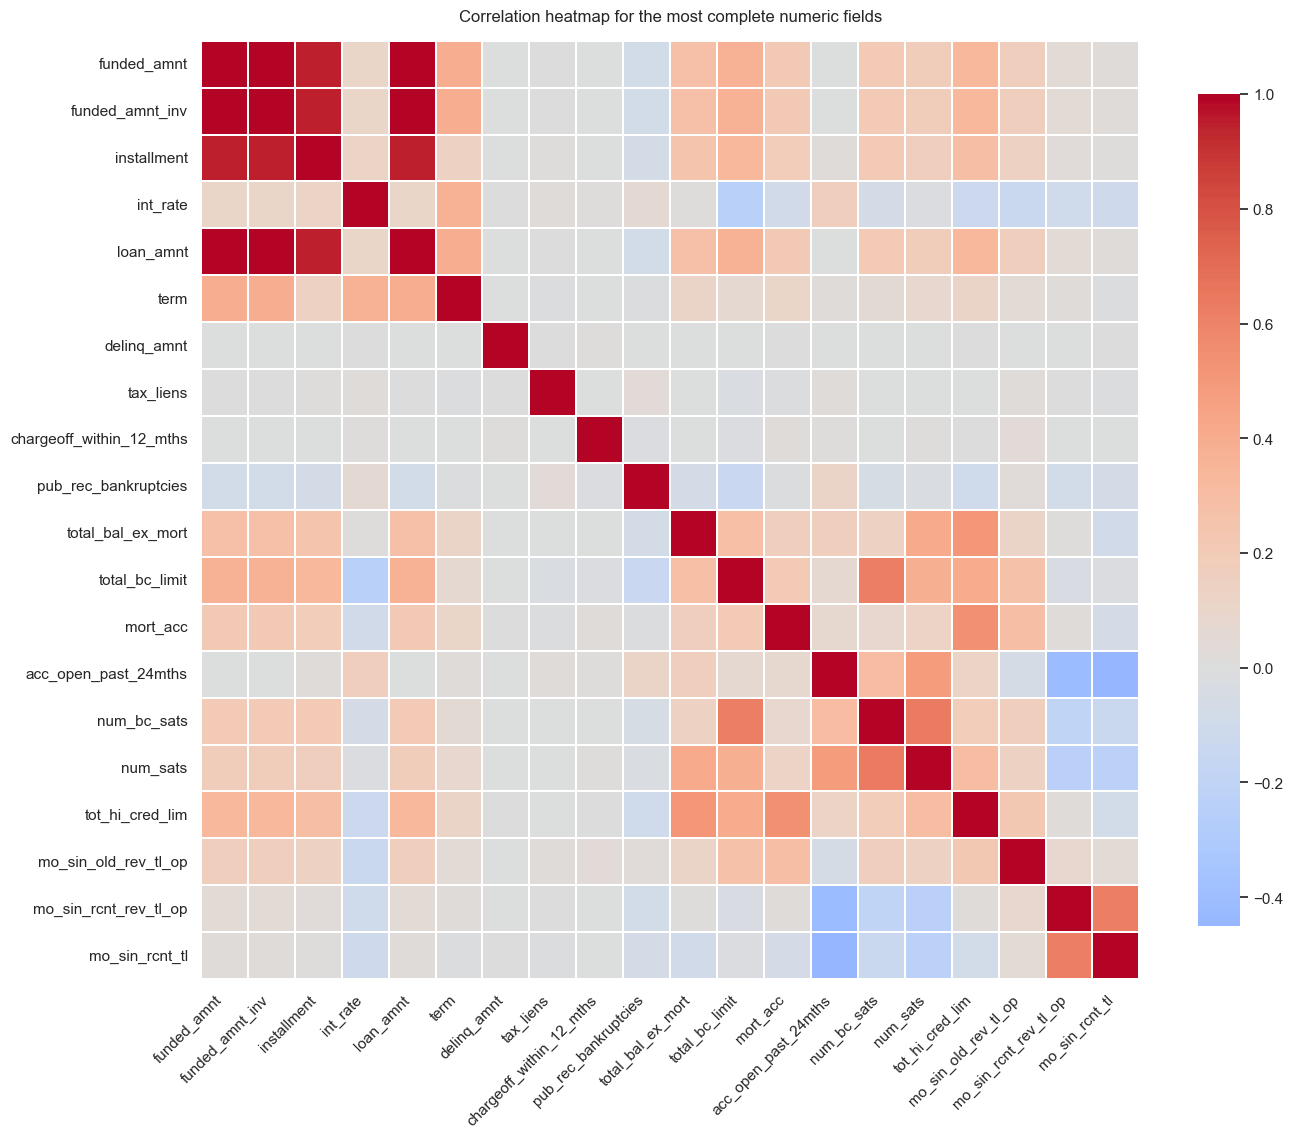

,metric_1,metric_2,correlation,abs_correlation
0,loan_amnt,funded_amnt,0.999763,0.999763
1,funded_amnt,funded_amnt_inv,0.999356,0.999356
2,loan_amnt,funded_amnt_inv,0.999064,0.999064
3,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.983188,0.983188
4,funded_amnt,installment,0.945316,0.945316
5,loan_amnt,installment,0.944996,0.944996
6,funded_amnt_inv,installment,0.944478,0.944478
7,mths_since_recent_bc_dlq,mths_since_recent_revol_delinq,0.890266,0.890266
8,total_bal_ex_mort,total_il_high_credit_limit,0.886245,0.886245
9,bc_open_to_buy,total_bc_limit,0.849676,0.849676


Wrote correlation workbook to /Users/tendani/Desktop/Loaning/data/numeric_correlations.xlsx


In [25]:
corr_matrix = numeric_pd_sample.corr(numeric_only=True)

corr_heatmap_columns = numeric_missing.loc[numeric_missing['missing_pct'] <= 0.25, 'column'].tolist()
corr_heatmap_columns = corr_heatmap_columns[:20] if corr_heatmap_columns else numeric_columns[:20]
corr_heatmap = corr_matrix.loc[corr_heatmap_columns, corr_heatmap_columns]

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_heatmap,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation heatmap for the most complete numeric fields', pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_pairs = (
    corr_matrix
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'metric_1', 'level_1': 'metric_2', 0: 'correlation'})
)

corr_pairs = corr_pairs[corr_pairs['metric_1'] != corr_pairs['metric_2']].copy()
corr_pairs['pair_key'] = corr_pairs.apply(
    lambda row: tuple(sorted((row['metric_1'], row['metric_2']))),
    axis=1
)
corr_pairs = corr_pairs.drop_duplicates('pair_key').drop(columns='pair_key')
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()

display(
    corr_pairs
    .sort_values('abs_correlation', ascending=False)
    .head(60)
    .reset_index(drop=True)
)

corr_export_path = DATA_DIR / 'numeric_correlations.xlsx'
corr_pairs_export = corr_pairs.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

with pd.ExcelWriter(corr_export_path, engine='openpyxl') as writer:
    corr_pairs_export.to_excel(writer, sheet_name='correlation_pairs', index=False)
    corr_matrix.to_excel(writer, sheet_name='correlation_matrix')
    corr_heatmap.to_excel(writer, sheet_name='heatmap_subset')

print(f'Wrote correlation workbook to {corr_export_path}')


,column,missing_pct,mean,std,min,p25,median,p75,p95,max
0,acc_open_past_24mths,2.21,4.522671,3.151786,0.00,2.000,4.00,6.00,10.00,49.00
1,bc_open_to_buy,3.31,11352.848205,16739.047292,0.00,1703.000,5421.00,14018.50,42459.10,357467.00
2,chargeoff_within_12_mths,0.02,0.007924,0.097809,0.00,0.000,0.00,0.00,0.00,4.00
3,delinq_amnt,0.01,12.932919,631.058515,0.00,0.000,0.00,0.00,0.00,65000.00
4,emp_length,6.50,5.935764,3.715272,0.00,2.000,6.00,10.00,10.00,10.00
5,funded_amnt,0.00,15005.805259,9165.001126,500.00,8000.000,12800.00,20000.00,35000.00,40000.00
6,funded_amnt_inv,0.00,14987.954669,9169.665362,0.00,8000.000,12800.00,20000.00,35000.00,40000.00
7,installment,0.00,444.557380,266.411043,16.73,251.335,376.59,590.68,982.02,1715.42
8,int_rate,0.00,13.095239,4.822783,5.31,9.490,12.62,15.99,22.15,30.99
9,loan_amnt,0.00,15011.177249,9166.160622,500.00,8000.000,12800.00,20000.00,35000.00,40000.00


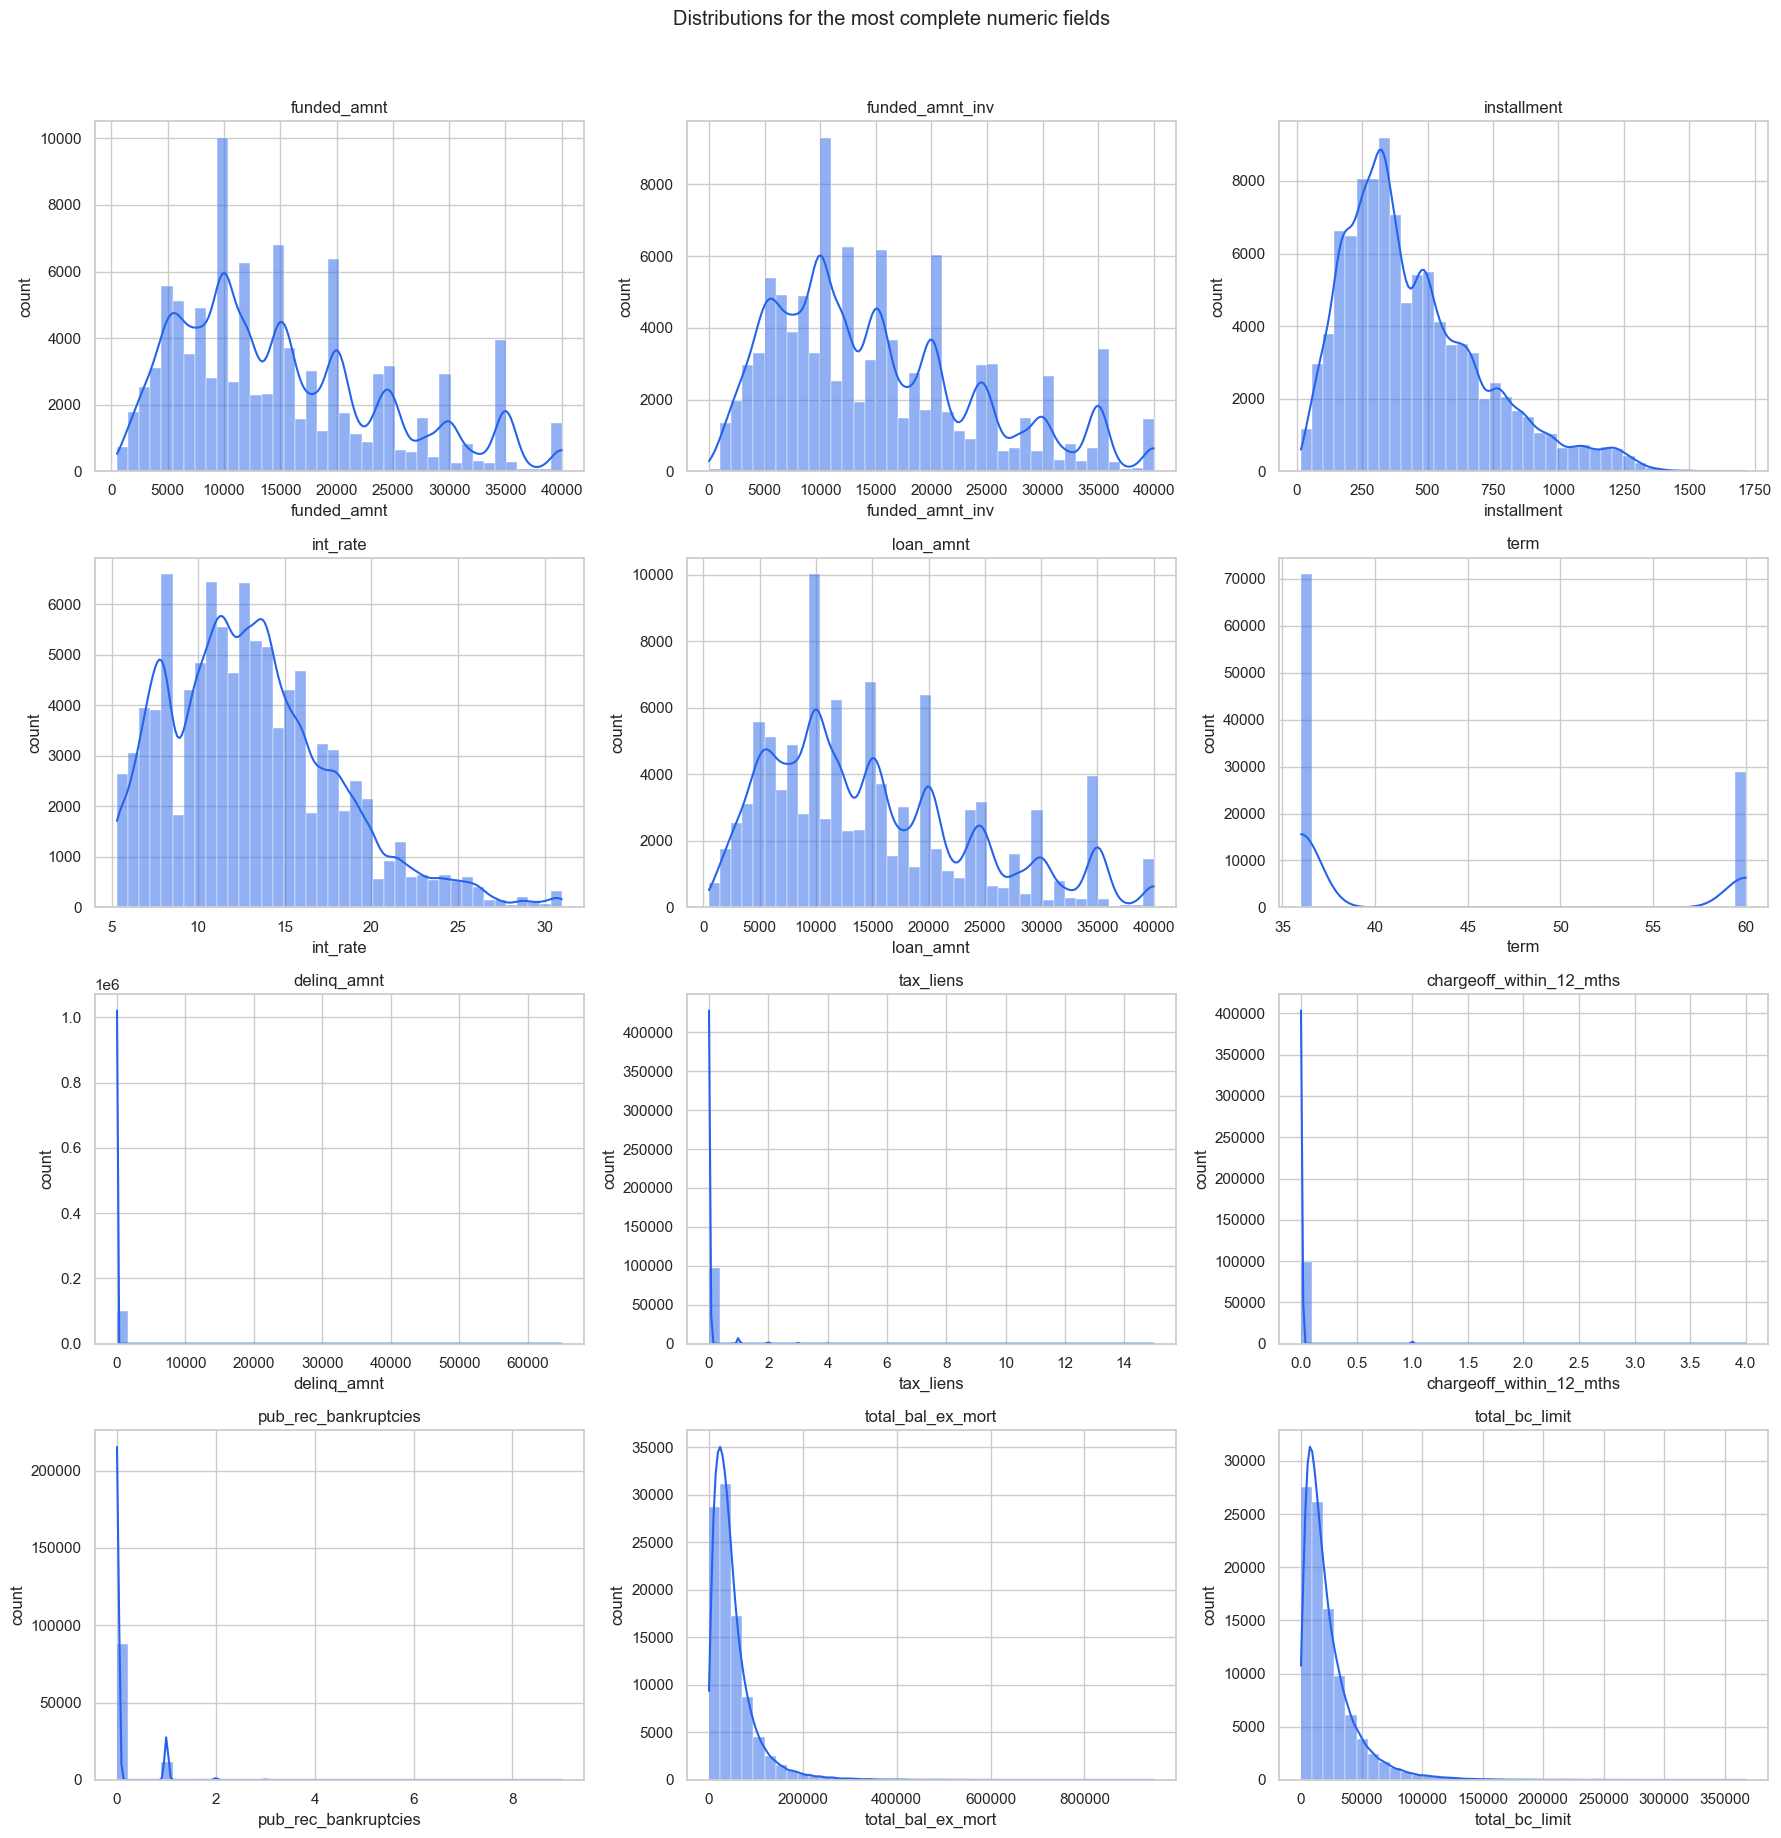

In [26]:
distribution_profile = pd.DataFrame({
    'column': numeric_pd_sample.columns,
    'mean': numeric_pd_sample.mean().values,
    'std': numeric_pd_sample.std().values,
    'min': numeric_pd_sample.min().values,
    'p25': numeric_pd_sample.quantile(0.25).values,
    'median': numeric_pd_sample.quantile(0.50).values,
    'p75': numeric_pd_sample.quantile(0.75).values,
    'p95': numeric_pd_sample.quantile(0.95).values,
    'max': numeric_pd_sample.max().values,
})

distribution_profile = distribution_profile.merge(numeric_missing, on='column', how='left')
distribution_profile['missing_pct'] = (distribution_profile['missing_pct'] * 100).round(2)
distribution_profile = distribution_profile[
    ['column', 'missing_pct', 'mean', 'std', 'min', 'p25', 'median', 'p75', 'p95', 'max']
].sort_values('column').reset_index(drop=True)

display(distribution_profile)

distribution_plot_columns = numeric_missing.loc[numeric_missing['missing_pct'] <= 0.10, 'column'].tolist()
distribution_plot_columns = distribution_plot_columns[:12] if distribution_plot_columns else numeric_columns[:12]

ncols = 3
nrows = math.ceil(len(distribution_plot_columns) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, column in zip(axes, distribution_plot_columns):
    series = numeric_pd_sample[column].dropna()
    sns.histplot(series, bins=40, kde=True, ax=ax, color='#2563eb', edgecolor='white', linewidth=0.3)
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel('count')

for ax in axes[len(distribution_plot_columns):]:
    ax.axis('off')

fig.suptitle('Distributions for the most complete numeric fields', y=1.02)
plt.tight_layout()
plt.show()


## Step 6: Define A Clean Modeling Target

The covariance and correlation work shows which numeric fields move together. The next modeling question is different: which fields separate resolved good loans from resolved bad loans? Start by converting `loan_status` into a binary `default_flag` and excluding unresolved outcomes such as `Current`, `Late`, and `In Grace Period`.


In [27]:
good_statuses = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid',
]

bad_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
]

unresolved_statuses = [
    'Current',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)',
]

# Prefer the cleaned in-memory frame when the notebook has been run from the top.
# Fall back to the Parquet frame if this section is being run independently.
df_model_source = df_step3_pruned if 'df_step3_pruned' in globals() else df_parquet

df_targeted = (
    df_model_source
    .withColumn(
        'default_flag',
        F.when(F.col('loan_status').isin(bad_statuses), F.lit(1.0))
         .when(F.col('loan_status').isin(good_statuses), F.lit(0.0))
         .otherwise(F.lit(None).cast('double'))
    )
    .filter(F.col('default_flag').isNotNull())
    .cache()
)

target_status_summary = (
    df_targeted
    .groupBy('loan_status', 'default_flag')
    .count()
    .orderBy('default_flag', 'loan_status')
)

target_status_summary.show(50, truncate=False)

resolved_row_count = df_targeted.count()
default_rate = df_targeted.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']

print(f'Resolved modeling rows: {resolved_row_count:,}')
print(f'Default rate among resolved loans: {default_rate:.2%}')
print(f'Excluded unresolved statuses: {unresolved_statuses}')


+---------------------------------------------------+------------+-------+
|loan_status                                        |default_flag|count  |
+---------------------------------------------------+------------+-------+
|Does not meet the credit policy. Status:Fully Paid |0.0         |1988   |
|Fully Paid                                         |0.0         |1041952|
|Charged Off                                        |1.0         |261654 |
|Default                                            |1.0         |31     |
|Does not meet the credit policy. Status:Charged Off|1.0         |761    |
+---------------------------------------------------+------------+-------+

Resolved modeling rows: 1,306,386
Default rate among resolved loans: 20.09%
Excluded unresolved statuses: ['Current', 'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)']


## Step 7: Exclude Leakage And Build Candidate Features

For an application-time underwriting model, do not train on columns that are only known after the loan is issued, such as payment history, recoveries, settlement fields, hardship outcomes, and last-payment dates. Also keep `grade`, `sub_grade`, `int_rate`, and `installment` out of the first independent baseline because they already encode Lending Club's own risk/pricing decision.


In [28]:
df_features = df_targeted
feature_dtypes = dict(df_features.dtypes)

# Make this section robust whether it receives the cleaned frame or the raw Parquet frame.
if feature_dtypes.get('term') == 'string':
    term_digits = F.regexp_extract(F.col('term'), r'(\d+)', 1)
    df_features = df_features.withColumn(
        'term',
        F.when(F.col('term').isNull(), None)
         .when(term_digits == '', None)
         .otherwise(term_digits.cast('int'))
    )

if feature_dtypes.get('emp_length') == 'string':
    emp_length_digits = F.regexp_extract(F.col('emp_length'), r'(\d+)', 1)
    df_features = df_features.withColumn(
        'emp_length',
        F.when(F.col('emp_length').isNull(), None)
         .when(F.col('emp_length') == '< 1 year', F.lit(0))
         .when(F.col('emp_length') == '10+ years', F.lit(10))
         .when(emp_length_digits == '', None)
         .otherwise(emp_length_digits.cast('int'))
    )

for c in ['issue_d', 'earliest_cr_line']:
    if c in df_features.columns and dict(df_features.dtypes).get(c) == 'string':
        df_features = df_features.withColumn(
            c,
            F.when(F.col(c).rlike(r'^[A-Za-z]{3}-\d{4}$'), F.to_date(F.col(c), 'MMM-yyyy'))
             .otherwise(None)
        )

if {'issue_d', 'earliest_cr_line'}.issubset(set(df_features.columns)):
    df_features = df_features.withColumn(
        'credit_history_months',
        F.when(
            F.col('issue_d').isNotNull() & F.col('earliest_cr_line').isNotNull(),
            F.months_between(F.col('issue_d'), F.col('earliest_cr_line'))
        )
    )

missing_flag_source_columns = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
]

for c in missing_flag_source_columns:
    if c in df_features.columns:
        df_features = df_features.withColumn(f'{c}_missing', F.col(c).isNull().cast('double'))

outcome_or_servicing_columns = {
    'loan_status',
    'default_flag',
    'funded_amnt',
    'funded_amnt_inv',
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',
    'pymnt_plan',
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term',
}

outcome_or_servicing_prefixes = (
    'hardship_',
    'settlement_',
)

pricing_or_lender_decision_columns = {
    'grade',
    'sub_grade',
    'int_rate',
    'installment',
}

identifier_or_raw_text_columns = {
    'id',
    'member_id',
    'url',
    'desc',
    'title',
    'title_normalized',
}

raw_date_or_audit_columns = {
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',
}

excluded_columns = (
    outcome_or_servicing_columns
    | pricing_or_lender_decision_columns
    | identifier_or_raw_text_columns
    | raw_date_or_audit_columns
    | {c for c in df_features.columns if c.endswith('_invalid_raw')}
    | {c for c in df_features.columns if c.startswith(outcome_or_servicing_prefixes)}
)

numeric_feature_candidates = [
    'loan_amnt',
    'term',
    'emp_length',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'collections_12_mths_ex_med',
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'mths_since_last_delinq_missing',
    'mths_since_last_record_missing',
    'mths_since_last_major_derog_missing',
    'acc_open_past_24mths',
    'mort_acc',
    'pub_rec_bankruptcies',
    'fico_range_low',
    'fico_range_high',
    'credit_history_months',
    'tot_coll_amt',
    'tot_cur_bal',
    'total_rev_hi_lim',
    'bc_util',
    'percent_bc_gt_75',
    'num_actv_bc_tl',
    'num_rev_tl_bal_gt_0',
    'num_tl_90g_dpd_24m',
    'pct_tl_nvr_dlq',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'open_il_12m',
    'open_il_24m',
    'open_rv_12m',
    'open_rv_24m',
    'inq_fi',
    'all_util',
]

categorical_feature_candidates = [
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type',
    'initial_list_status',
    'disbursement_method',
    'title_grouped',
]


spark_numeric_types = {
    'byte',
    'short',
    'int',
    'bigint',
    'long',
    'float',
    'double',
}

for c in numeric_feature_candidates:
    if c in df_features.columns:
        current_type = dict(df_features.dtypes).get(c, '')
        is_decimal = current_type.startswith('decimal')
        if current_type not in spark_numeric_types and not is_decimal:
            escaped_column = c.replace('`', '``')
            df_features = df_features.withColumn(
                c,
                F.expr(
                    f"try_cast(regexp_replace(cast(`{escaped_column}` as string), '[%$,]', '') as double)"
                )
            )

numeric_feature_cols = [
    c for c in numeric_feature_candidates
    if c in df_features.columns and c not in excluded_columns
]

categorical_feature_cols = [
    c for c in categorical_feature_candidates
    if c in df_features.columns and c not in excluded_columns
]

feature_inventory = pd.DataFrame(
    [{'column': c, 'role': 'numeric'} for c in numeric_feature_cols]
    + [{'column': c, 'role': 'categorical'} for c in categorical_feature_cols]
)

display(feature_inventory)

print(f'Numeric baseline candidates: {len(numeric_feature_cols)}')
print(f'Categorical baseline candidates: {len(categorical_feature_cols)}')
print(f'Excluded leakage/pricing/raw columns present: {len([c for c in excluded_columns if c in df_features.columns])}')


,column,role
0,loan_amnt,numeric
1,term,numeric
2,emp_length,numeric
3,annual_inc,numeric
4,dti,numeric
5,delinq_2yrs,numeric
6,inq_last_6mths,numeric
7,open_acc,numeric
8,pub_rec,numeric
9,revol_bal,numeric


Numeric baseline candidates: 41
Categorical baseline candidates: 7
Excluded leakage/pricing/raw columns present: 50


## Step 8: Rank Numeric Features Against The Target

This is a better next screen than the covariance matrix for modeling. It estimates each numeric feature's simple correlation with `default_flag`, while still treating the result as a first-pass signal rather than final feature importance.


,column,correlation_with_default,abs_correlation,sample_missing_pct
0,term,0.178829,0.178829,0.000000
1,acc_open_past_24mths,0.098476,0.098476,0.039201
2,all_util,0.092176,0.092176,0.618004
3,dti,0.086359,0.086359,0.000500
4,open_rv_24m,0.078482,0.078482,0.617944
5,mort_acc,-0.077537,0.077537,0.039201
6,tot_cur_bal,-0.073499,0.073499,0.054239
7,open_rv_12m,0.071078,0.071078,0.617954
8,inq_last_6mths,0.067593,0.067593,0.000160
9,num_rev_tl_bal_gt_0,0.067524,0.067524,0.054289


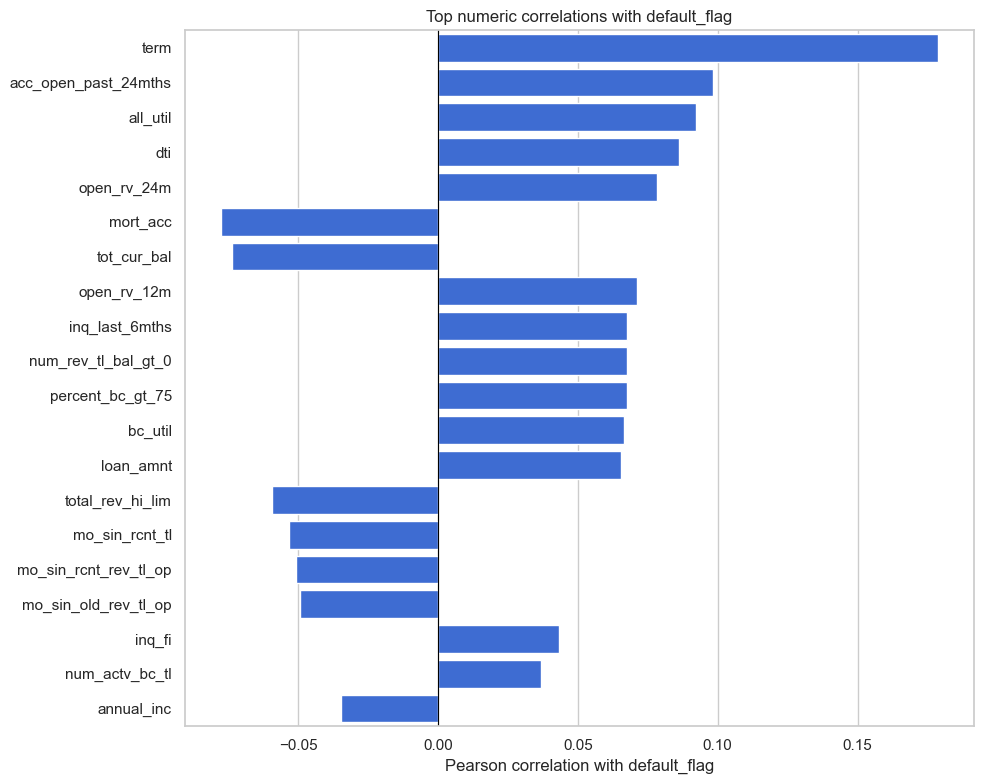

In [29]:
df_features = df_features.cache()
feature_row_count = df_features.count()

feature_sample_target = 100_000
feature_sample_fraction = min(1.0, feature_sample_target / feature_row_count)

feature_corr_pd = (
    df_features
    .select(['default_flag'] + numeric_feature_cols)
    .sample(False, feature_sample_fraction, seed=42)
    .limit(feature_sample_target)
    .toPandas()
    .apply(pd.to_numeric, errors='coerce')
)

target_correlations = (
    feature_corr_pd
    .corr(numeric_only=True)['default_flag']
    .drop(labels=['default_flag'])
    .reset_index()
    .rename(columns={'index': 'column', 'default_flag': 'correlation_with_default'})
)

target_correlations['abs_correlation'] = target_correlations['correlation_with_default'].abs()

feature_missing_pd = (
    feature_corr_pd[numeric_feature_cols]
    .isna()
    .mean()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'sample_missing_pct'})
)

target_feature_screen = (
    target_correlations
    .merge(feature_missing_pd, on='column', how='left')
    .sort_values('abs_correlation', ascending=False)
    .reset_index(drop=True)
)

display(target_feature_screen.head(40))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=target_feature_screen.head(20),
    y='column',
    x='correlation_with_default',
    color='#2563eb'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top numeric correlations with default_flag')
plt.xlabel('Pearson correlation with default_flag')
plt.ylabel('')
plt.tight_layout()
plt.show()


## Step 9: Train A First Baseline Model

Use this model as a sanity check, not as the final underwriting model. The point is to test whether the cleaned, leakage-controlled feature set can predict resolved defaults better than chance and to produce an initial model-based feature ranking.


In [30]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import Imputer, OneHotEncoder, StringIndexer, VectorAssembler

model_sample_target = 250_000
model_sample_fraction = min(1.0, model_sample_target / feature_row_count)

model_input = (
    df_features
    .select(['default_flag'] + numeric_feature_cols + categorical_feature_cols)
    .sample(False, model_sample_fraction, seed=7)
    .limit(model_sample_target)
    .cache()
)

model_input_count = model_input.count()
print(f'Modeling sample rows: {model_input_count:,}')

numeric_non_null_counts = model_input.select([
    F.count(F.col(c)).alias(c)
    for c in numeric_feature_cols
]).first().asDict() if numeric_feature_cols else {}

categorical_non_null_counts = model_input.select([
    F.count(F.col(c)).alias(c)
    for c in categorical_feature_cols
]).first().asDict() if categorical_feature_cols else {}

model_numeric_cols = [c for c in numeric_feature_cols if numeric_non_null_counts.get(c, 0) > 0]
model_categorical_cols = [c for c in categorical_feature_cols if categorical_non_null_counts.get(c, 0) > 0]

numeric_imputed_cols = [f'{c}_imputed' for c in model_numeric_cols]
categorical_indexed_cols = [f'{c}_idx' for c in model_categorical_cols]
categorical_encoded_cols = [f'{c}_encoded' for c in model_categorical_cols]

stages = []

if model_numeric_cols:
    stages.append(Imputer(
        inputCols=model_numeric_cols,
        outputCols=numeric_imputed_cols,
        strategy='median'
    ))

if model_categorical_cols:
    stages.extend([
        StringIndexer(
            inputCols=model_categorical_cols,
            outputCols=categorical_indexed_cols,
            handleInvalid='keep'
        ),
        OneHotEncoder(
            inputCols=categorical_indexed_cols,
            outputCols=categorical_encoded_cols
        )
    ])

assembler_inputs = numeric_imputed_cols + categorical_encoded_cols

stages.extend([
    VectorAssembler(
        inputCols=assembler_inputs,
        outputCol='features',
        handleInvalid='keep'
    ),
    LogisticRegression(
        featuresCol='features',
        labelCol='default_flag',
        maxIter=50,
        regParam=0.01,
        elasticNetParam=0.0
    )
])

train_df, test_df = model_input.randomSplit([0.8, 0.2], seed=42)

baseline_pipeline = Pipeline(stages=stages)
baseline_model = baseline_pipeline.fit(train_df)
baseline_predictions = baseline_model.transform(test_df).cache()

roc_auc = BinaryClassificationEvaluator(
    labelCol='default_flag',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
).evaluate(baseline_predictions)

pr_auc = BinaryClassificationEvaluator(
    labelCol='default_flag',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderPR'
).evaluate(baseline_predictions)

print(f'Baseline ROC AUC: {roc_auc:.4f}')
print(f'Baseline PR AUC: {pr_auc:.4f}')

prediction_summary = (
    baseline_predictions
    .groupBy('default_flag', 'prediction')
    .count()
    .orderBy('default_flag', 'prediction')
    .toPandas()
)

display(prediction_summary)


Modeling sample rows: 249,955


26/06/06 20:34:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/06 20:34:07 WARN DAGScheduler: Broadcasting large task binary with size 1152.4 KiB
26/06/06 20:34:09 WARN DAGScheduler: Broadcasting large task binary with size 1152.4 KiB


Baseline ROC AUC: 0.6987
Baseline PR AUC: 0.3668


26/06/06 20:34:09 WARN DAGScheduler: Broadcasting large task binary with size 1165.8 KiB


,default_flag,prediction,count
0,0.0,0.0,39691
1,0.0,1.0,466
2,1.0,0.0,9472
3,1.0,1.0,548


In [31]:
lr_model = baseline_model.stages[-1]
feature_metadata = baseline_predictions.schema['features'].metadata.get('ml_attr', {}).get('attrs', {})

feature_attrs = []
for attrs in feature_metadata.values():
    feature_attrs.extend(attrs)

feature_names = [
    attr['name']
    for attr in sorted(feature_attrs, key=lambda attr: attr['idx'])
]

coef_values = lr_model.coefficients.toArray()

if len(feature_names) == len(coef_values):
    coefficient_ranking = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coef_values,
    })
else:
    coefficient_ranking = pd.DataFrame({
        'feature': [f'feature_{i}' for i in range(len(coef_values))],
        'coefficient': coef_values,
    })

coefficient_ranking['abs_coefficient'] = coefficient_ranking['coefficient'].abs()
coefficient_ranking = coefficient_ranking.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

display(coefficient_ranking.head(40))

print('Positive coefficients push predicted default risk up; negative coefficients push it down.')
print('Because this is logistic regression on mixed scales, treat this as a baseline diagnostic, not final feature importance.')


,feature,coefficient,abs_coefficient
0,purpose_encoded_and always kept the best inter...,13.657364,13.657364
1,initial_list_status_encoded_59.1,13.657364,13.657364
2,title_grouped_encoded_fixed loan,5.734597,5.734597
3,title_grouped_encoded_giving the 99% a chance ...,5.475725,5.475725
4,title_grouped_encoded_second loan with lending...,5.365299,5.365299
5,title_grouped_encoded_consloan,5.336378,5.336378
6,title_grouped_encoded_timeshare payoff,5.329275,5.329275
7,title_grouped_encoded_kill the card,5.320887,5.320887
8,purpose_encoded_and transparent relationship b...,-5.304045,5.304045
9,title_grouped_encoded_lc funds,5.294706,5.294706


Positive coefficients push predicted default risk up; negative coefficients push it down.
Because this is logistic regression on mixed scales, treat this as a baseline diagnostic, not final feature importance.


## Practical Next Moves

After this baseline runs, compare it against a second benchmark model that includes `grade`, `sub_grade`, `int_rate`, and `installment`. If that benchmark is much stronger, it means Lending Club's own pricing variables carry a lot of the signal. After that, move to tree-based models and permutation importance for a stronger feature-importance view.


In [20]:
spark.stop()